# Insurance Claim Prediction — Machine Learning

**Objective:** Build and train three predictive models to classify insurance claims:
1. **Logistic Regression** — Interpretable baseline model
2. **Random Forest** — Ensemble of decision trees
3. **XGBoost** — Optimized gradient boosting

**Dataset:** 50,000 policyholders, target = `Claim` (0/1)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load and Inspect Data

In [2]:
X_train_processed = pd.read_csv('../data/X_train.csv')
X_test_processed = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv', index_col=0).squeeze('columns')
y_test = pd.read_csv('../data/y_test.csv', index_col=0).squeeze('columns')
all_features = pd.read_csv('../data/feature_names.csv')['feature'].tolist()

print(f'X_train_processed: {X_train_processed.shape}, y_train: {y_train.shape}')
print(f'X_test_processed:  {X_test_processed.shape}, y_test:  {y_test.shape}')
print(f'Features: {len(all_features)}')
print(f'Train claim rate: {y_train.mean()*100:.2f}%')
print(f'Test claim rate:  {y_test.mean()*100:.2f}%')

X_train_processed: (40000, 49), y_train: (40000,)
X_test_processed:  (10000, 49), y_test:  (10000,)
Features: 49
Train claim rate: 17.64%
Test claim rate:  17.64%


## 3. Model 1: Logistic Regression

**Why Logistic Regression?** Industry standard in insurance, highly interpretable, well-calibrated probabilities.

In [3]:
print('=' * 60)
print('MODEL 1: LOGISTIC REGRESSION')
print('=' * 60)

lr_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)

print('\nTraining Logistic Regression with hyperparameter tuning...')
lr_grid.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {lr_grid.best_params_}')
print(f'Best CV ROC-AUC: {lr_grid.best_score_:.4f}')

lr_best = lr_grid.best_estimator_

y_pred_lr = lr_best.predict(X_test_processed)
y_prob_lr = lr_best.predict_proba(X_test_processed)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_acc = accuracy_score(y_test, y_pred_lr)
print(f'\nTest ROC-AUC: {lr_auc:.4f}')
print(f'Test Accuracy: {lr_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

MODEL 1: LOGISTIC REGRESSION

Training Logistic Regression with hyperparameter tuning...
Fitting 5 folds for each of 16 candidates, totalling 80 fits



Best Parameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.6795

Test ROC-AUC: 0.6878
Test Accuracy: 0.8269

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8236
           1       0.58      0.07      0.12      1764

    accuracy                           0.83     10000
   macro avg       0.71      0.53      0.51     10000
weighted avg       0.79      0.83      0.77     10000



### Logistic Regression Coefficients

One of the biggest advantages of Logistic Regression is interpretability.

In [4]:
# Feature names loaded from pre-processing notebook output (all_features)

coefficients = lr_best.coef_[0]
intercept = lr_best.intercept_[0]

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print(f'Intercept: {intercept:.4f}')
print(f'\nTop 20 Most Important Features (by absolute coefficient):')
print('=' * 70)
print(f'{"Feature":35s} {"Coefficient":>12s}')
print('=' * 70)
for _, row in coef_df.head(20).iterrows():
    direction = 'Higher Risk' if row['Coefficient'] > 0 else 'Lower Risk'
    print(f"{row['Feature']:35s} {row['Coefficient']:>+12.4f}  {direction}")

coef_df.to_csv('../models/lr_coefficients.csv', index=False)
print('\nCoefficients saved to models/lr_coefficients.csv')

Intercept: -1.7356

Top 20 Most Important Features (by absolute coefficient):
Feature                              Coefficient
Policy_Type_Premium                      -0.7177  Lower Risk
Exp_Ratio                                -0.5129  Lower Risk
Driving_Experience                       +0.3245  Higher Risk
Policy_Type_Standard                     -0.3152  Lower Risk
Region_South                             +0.3025  Higher Risk
Annual_Premium                           +0.2899  Higher Risk
Parking_Type_Street                      +0.2823  Higher Risk
Vehicle_Type_Sports Car                  +0.2762  Higher Risk
Age_Group_YoungAdult                     -0.2456  Lower Risk
Years_Licensed                           +0.2211  Higher Risk
Age                                      -0.1946  Lower Risk
Urban_Rural_Urban                        +0.1869  Higher Risk
Credit_Score                             -0.1777  Lower Risk
Risk_Score                               +0.1394  Higher Risk
Vehicle_Typ

## 4. Model 2: Random Forest

**Why Random Forest?** Captures non-linear relationships, feature interactions, robust to outliers.

In [5]:
print('=' * 60)
print('MODEL 2: RANDOM FOREST')
print('=' * 60)

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, verbose=0),
    param_distributions=rf_param_grid,
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1,
    random_state=42
)

print('\nTraining Random Forest with hyperparameter tuning...')
rf_random.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {rf_random.best_params_}')
print(f'Best CV ROC-AUC: {rf_random.best_score_:.4f}')

rf_best = rf_random.best_estimator_

y_pred_rf = rf_best.predict(X_test_processed)
y_prob_rf = rf_best.predict_proba(X_test_processed)[:, 1]

rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'\nTest ROC-AUC: {rf_auc:.4f}')
print(f'Test Accuracy: {rf_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

MODEL 2: RANDOM FOREST

Training Random Forest with hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best Parameters: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None}
Best CV ROC-AUC: 0.6747

Test ROC-AUC: 0.6831
Test Accuracy: 0.8277

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8236
           1       0.61      0.07      0.12      1764

    accuracy                           0.83     10000
   macro avg       0.72      0.53      0.51     10000
weighted avg       0.79      0.83      0.77     10000



### Random Forest Feature Importance

Top 20 Most Important Features (Random Forest):
Exp_Ratio                           0.0905  |||||||||
Driving_Experience                  0.0850  ||||||||
Age                                 0.0792  |||||||
Credit_Score                        0.0670  ||||||
Years_Licensed                      0.0610  ||||||
Risk_Score                          0.0576  |||||
Annual_Premium                      0.0524  |||||
Premium_Income_Ratio                0.0422  ||||
Vehicle_Value                       0.0416  ||||
Annual_Mileage                      0.0409  ||||
Age_Group_Young                     0.0405  ||||
Annual_Income                       0.0366  |||
Coverage_Amount                     0.0345  |||
Crime_Index                         0.0319  |||
Engine_Size                         0.0317  |||
Traffic_Violations                  0.0287  ||
Parking_Type_Street                 0.0185  |
Previous_Claims                     0.0182  |
Vehicle_Age                         0.0164  |
Vehicle_Type_Sport

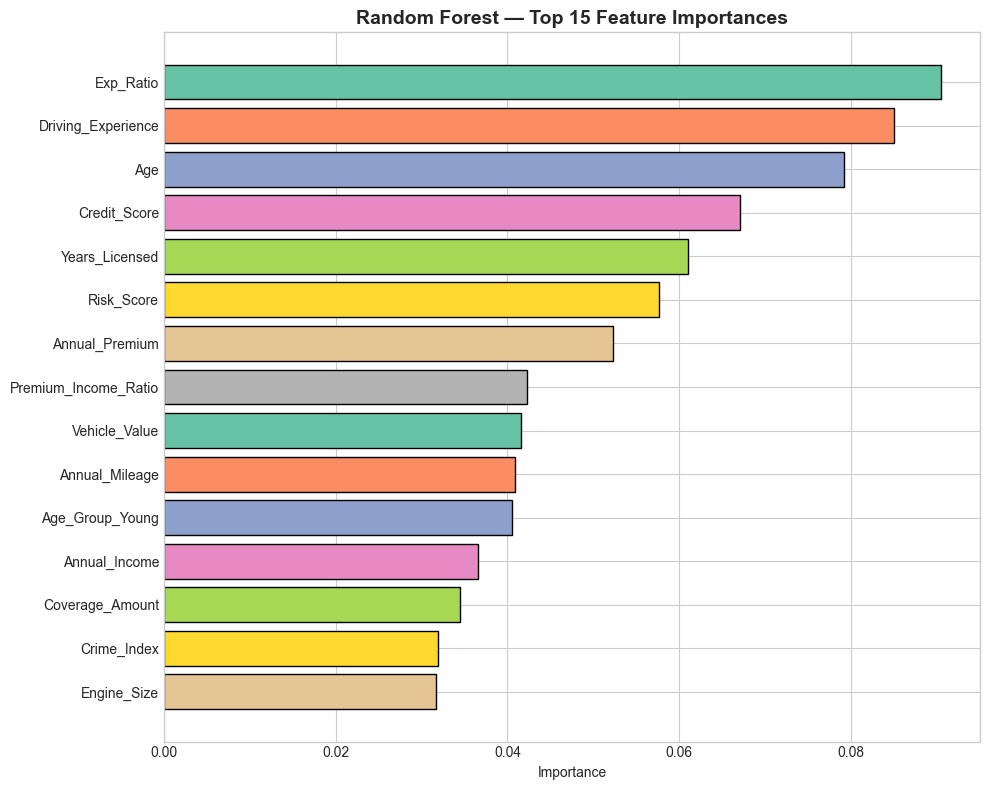


Feature importance saved.


In [6]:
rf_importance = rf_best.feature_importances_
rf_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

print('Top 20 Most Important Features (Random Forest):')
print('=' * 60)
for _, row in rf_imp_df.head(20).iterrows():
    bar = '|' * int(row['Importance'] * 100)
    print(f"{row['Feature']:35s} {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
top_features = rf_imp_df.head(15)
ax.barh(range(len(top_features)), top_features['Importance'].values,
        color=sns.color_palette('Set2'), edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

rf_imp_df.to_csv('../models/rf_feature_importance.csv', index=False)
print('\nFeature importance saved.')

## 5. Model 3: XGBoost

**Why XGBoost?** State-of-the-art gradient boosting, built-in regularization, handles missing values.

In [7]:
print('=' * 60)
print('MODEL 3: XGBOOST')
print('=' * 60)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 2.0, 3.0],
    'scale_pos_weight': [1, 4, 7]
}

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, verbosity=0,
                      use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1,
    random_state=42
)

print('\nTraining XGBoost with hyperparameter tuning...')
xgb_random.fit(X_train_processed, y_train)

print(f'\nBest Parameters: {xgb_random.best_params_}')
print(f'Best CV ROC-AUC: {xgb_random.best_score_:.4f}')

xgb_best = xgb_random.best_estimator_

y_pred_xgb = xgb_best.predict(X_test_processed)
y_prob_xgb = xgb_best.predict_proba(X_test_processed)[:, 1]

xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f'\nTest ROC-AUC: {xgb_auc:.4f}')
print(f'Test Accuracy: {xgb_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

MODEL 3: XGBOOST

Training XGBoost with hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.6809

Test ROC-AUC: 0.6872
Test Accuracy: 0.8263

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      8236
           1       0.56      0.08      0.13      1764

    accuracy                           0.83     10000
   macro avg       0.69      0.53      0.52     10000
weighted avg       0.78      0.83      0.77     10000



### XGBoost Feature Importance

Top 20 Most Important Features (XGBoost):
Age                                 0.2795  |||||||||||||||||||||||||||
Driving_Experience                  0.1073  ||||||||||
Risk_Score                          0.0598  |||||
Vehicle_Type_Sports Car             0.0424  ||||
Exp_Ratio                           0.0390  |||
Parking_Type_Street                 0.0381  |||
Years_Licensed                      0.0372  |||
Region_South                        0.0285  ||
Credit_Score                        0.0272  ||
Age_Group_Senior                    0.0241  ||
Urban_Rural_Urban                   0.0226  ||
Marital_Status_Widowed              0.0186  |
Annual_Premium                      0.0169  |
Age_Group_MiddleAge                 0.0150  |
Traffic_Violations                  0.0145  |
Engine_Size                         0.0138  |
Vehicle_Type_Truck                  0.0134  |
Annual_Mileage                      0.0134  |
Previous_Claims                     0.0126  |
Gender_Male                     

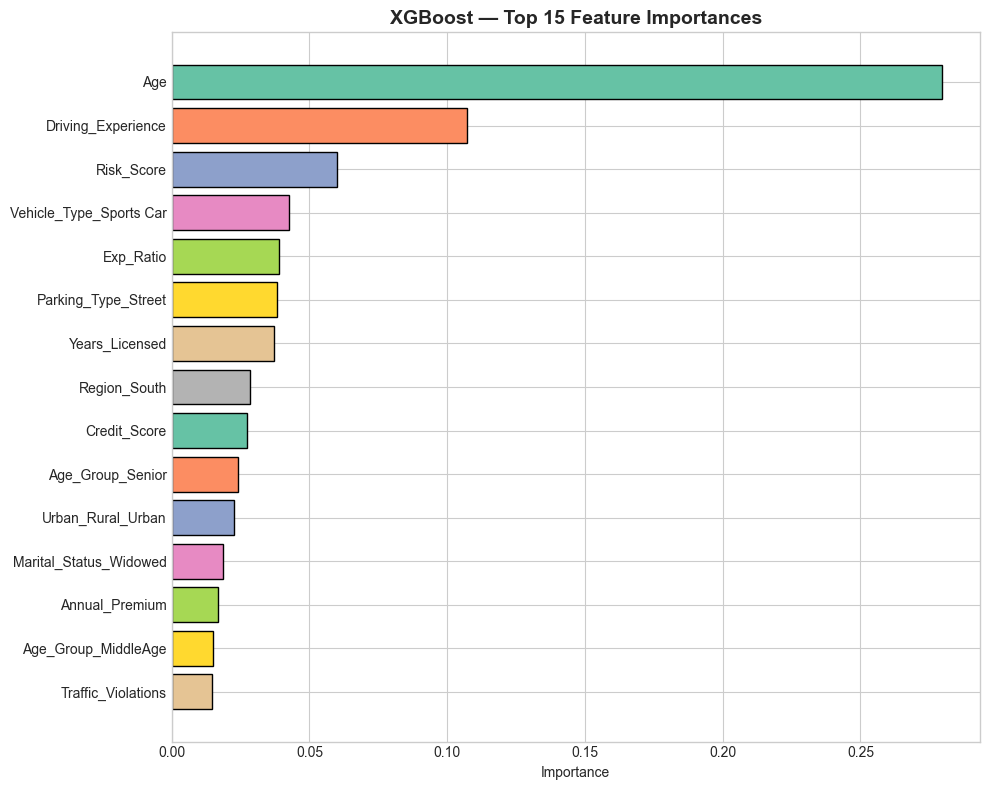


Feature importance saved.


In [8]:
xgb_importance = xgb_best.feature_importances_
xgb_imp_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

print('Top 20 Most Important Features (XGBoost):')
print('=' * 60)
for _, row in xgb_imp_df.head(20).iterrows():
    bar = '|' * int(row['Importance'] * 100)
    print(f"{row['Feature']:35s} {row['Importance']:.4f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 8))
top_features = xgb_imp_df.head(15)
ax.barh(range(len(top_features)), top_features['Importance'].values,
        color=sns.color_palette('Set2'), edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('XGBoost — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

xgb_imp_df.to_csv('../models/xgb_feature_importance.csv', index=False)
print('\nFeature importance saved.')

## 6. Save Models and Predictions

In [9]:
os.makedirs('../models', exist_ok=True)

models = {
    'logistic_regression': lr_best,
    'random_forest': rf_best,
    'xgboost': xgb_best
}

for name, model in models.items():
    path = f'../models/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

predictions_df = pd.DataFrame({
    'y_test': y_test,
    'y_prob_lr': y_prob_lr, 'y_pred_lr': y_pred_lr,
    'y_prob_rf': y_prob_rf, 'y_pred_rf': y_pred_rf,
    'y_prob_xgb': y_prob_xgb, 'y_pred_xgb': y_pred_xgb,
})
predictions_df.to_csv('../models/test_predictions.csv', index=False)
print('Test predictions saved to models/test_predictions.csv')

Saved: ../models/logistic_regression.pkl
Saved: ../models/random_forest.pkl
Saved: ../models/xgboost.pkl
Test predictions saved to models/test_predictions.csv


## 7. Quick Summary

In [10]:
print('=' * 60)
print('MODEL COMPARISON (TEST SET)')
print('=' * 60)
print(f'{"Model":25s} {"Accuracy":>10s} {"ROC-AUC":>10s}')
print('-' * 60)
print(f'{"Logistic Regression":25s} {lr_acc:>10.4f} {lr_auc:>10.4f}')
print(f'{"Random Forest":25s} {rf_acc:>10.4f} {rf_auc:>10.4f}')
print(f'{"XGBoost":25s} {xgb_acc:>10.4f} {xgb_auc:>10.4f}')
print('-' * 60)

print('\nNEXT STEP: Open 04_ModelEvaluation.ipynb for detailed comparison')

MODEL COMPARISON (TEST SET)
Model                       Accuracy    ROC-AUC
------------------------------------------------------------
Logistic Regression           0.8269     0.6878
Random Forest                 0.8277     0.6831
XGBoost                       0.8263     0.6872
------------------------------------------------------------
\nNEXT STEP: Open 04_ModelEvaluation.ipynb for detailed comparison
